#  Sequential Forward Selection 

**Sequential Forward Selection (SFS)** is a **supervised, greedy, wrapper-based** feature selection algorithm. 

While **Exhaustive Feature Selection (EFS)** evaluates every single possible combination of features to guarantee a global mathematical optimum, its exponential time complexity $\mathcal{O}(2^N)$ makes it impossible to scale to large datasets. SFS solves this bottleneck by employing a **greedy search heuristic**. Instead of checking every combination, it builds a feature subset step-by-step, making the locally optimal choice at each stage with the goal of finding a strong, generalized feature set in a fraction of the time.



## 1. Algorithmic Workflow & Architecture

SFS functions as a bottom-up iterative search engine. It starts with an empty set of features and adds one feature at a time based on model performance.

### The Step-by-Step Mechanism
1.  **Initialization:** Start with an empty feature subset: $Y_0 = \emptyset$.

2.  **Step 1 Evaluation:** Train your chosen wrapper model N times, each time using exactly one feature from your total pool of N features. Measure the cross-validated validation score for each.
3.  **Selection:** Identify the single feature that yielded the absolute highest model performance metric. Add this feature to your subset: $Y_1 = \{X_{\text{best\_1}}\}$.

4.  **Step 2 Evaluation:** Pair your selected feature $X_{\text{best\_1}}$ individually with every remaining N-1 feature. Train the model on these pairs.
5.  **Iteration:** Identify the pair that performs best. Add the new feature to your subset: $Y_2 = \{X_{\text{best\_1}}, X_{\text{best\_2}}\}$.

6.  **Termination Rule:** Repeat this process, adding one feature per step. The algorithm stops when it reaches a user-defined target number of features, or when adding a new feature fails to improve the cross-validated model score by a significant threshold.

### Mathematical & Computational Efficiency
Instead of evaluating $2^N$ combinations, SFS dramatically compresses the search space. If you want to select a subset of size k out of N total features, the total number of models trained (M) is calculated by:

$$M = \sum_{i=0}^{k-1} (N - i) = k \cdot N - \frac{k(k-1)}{2}$$

#### The Scalability Comparison (At N = 30 features, aiming for a subset of k = 5):

*   **Exhaustive Search (EFS):** Evaluates $\binom{30}{5} = \mathbf{142,506\text{ models}}$
*   **Sequential Forward Selection (SFS):** Evaluates $30 + 29 + 28 + 27 + 26 = \mathbf{140\text{ models}}$


In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector as SFS_sk
from mlxtend.feature_selection import SequentialFeatureSelector as SFS_mlx

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


# 1. Load Dataset & Inspect

In [123]:
# Importing Dataset
df = pd.read_csv("../DataSets/HousingData.csv")
print(f"Number of features : {len(df.columns)}")
df.sample(5)

Number of features : 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
260,0.54011,20.0,3.97,0.0,0.647,7.203,81.8,2.1121,5,264,13.0,392.80,9.59,33.8
104,0.13960,0.0,8.56,0.0,0.520,6.167,90.0,2.4210,5,384,20.9,392.69,12.33,20.1
205,0.13642,NaN,10.59,0.0,0.489,5.891,22.3,3.9454,4,277,18.6,396.90,10.87,22.6
351,0.07950,60.0,1.69,0.0,0.411,6.579,35.9,10.7103,4,411,18.3,370.78,5.49,24.1
358,5.20177,0.0,18.10,1.0,0.770,6.127,83.4,2.7227,24,666,20.2,395.43,11.48,22.7


Boston Housing — 506 neighborhoods, 13 predictors, target `MEDV` (median
home value in $1000s).

In [124]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [125]:
# Missing Value
print(f" Missing Value:\n{df.isna().sum()[df.isna().sum()>0]}")
print(f"Total Number of Missing Values : {df.isnull().sum().sum()}")

 Missing Value:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64
Total Number of Missing Values : 120


**Observation:** Six columns carry 20 missing values each we will use Median imputation as it's robust to the heavy skew in features like `CRIM`, and it's applied before any selection so every subset is evaluated on identical data.

>NOTE: Imputing on the full dataset before cross-validation leaks a small amount of information across folds (the median is computed using rows that later appear in validation folds). The strictly correct approach puts the imputer inside the CV pipeline. The effect here is negligible '20' values per column out of 506 is not a big deal, but it's worth noting.

In [126]:
# For now let's fill the missing values using their median
df = df.fillna(df.median())

feature_name = [name for name in df.columns if name != 'MEDV']
X = df[feature_name].values
y = df['MEDV'].values

print(f"Features : {feature_name}")
print(f"Number of Features : {len(feature_name)}")
print(f"Null Values : {np.isnan(X).sum()}")

Features : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Number of Features : 13
Null Values : 0


# 2. Correlation Matrix

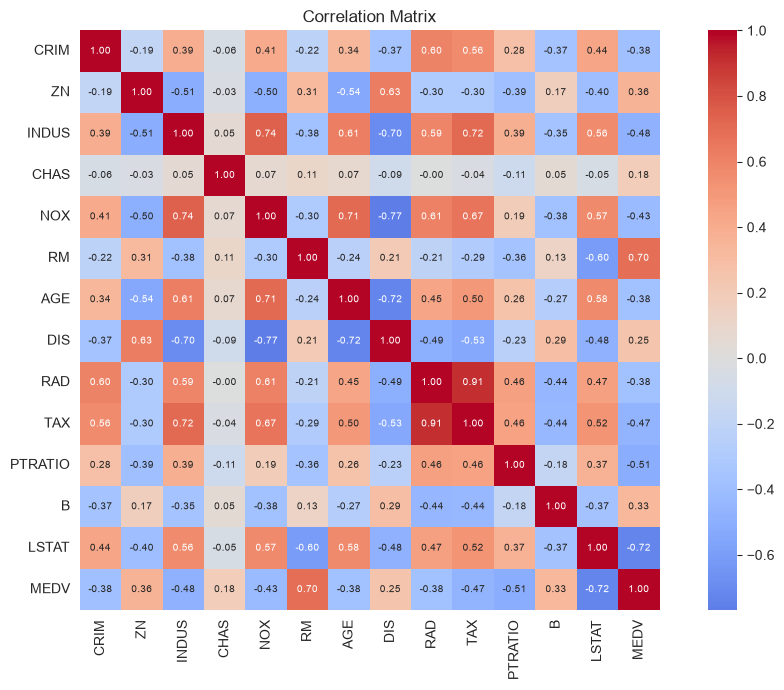

In [6]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, annot_kws={'size':7})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** 
1. `LSTAT` (% lower-status population) and `RM` (rooms per dwelling) show the strongest raw correlation with `MEDV`. Worth holding onto as a sanity check. If forward selection's *first two picks* aren't these, something would be off.

2. Note also `RAD`/`TAX` are strongly correlated with each other (~0.91), which is the kind of redundancy a greedy forward search handles   implicitly: once one is in, the other adds little, so it tends not to get picked next.

# 3. Forward Selection -  Implementation


The algorithm:

- Start with an empty set of selected features.
- At each round, try adding each remaining feature one at a time, score
  each candidate by cross-validated R², and permanently add the single
  best one.
- Repeat until no features remain, logging the score at every step.

Running it all the way to 13 (rather than stopping at the first
non-improvement) gives the **full score-vs-size curve**, which is what
makes the stopping decision visible instead of hidden inside the loop.

### 3.1 Forward Selection Method

In [ ]:
def make_reg():
    return make_pipeline(StandardScaler(), LinearRegression())


def forward_selection(X, y, feature_names, cv, scoring='r2'):
    n_features = X.shape[1] # Number of features in the dataset
    selected = [] # selected features
    remaining = list(range(n_features)) # List of all remaining features
    history=[] # Store the history of selected features
    n_evaluation = 0 # counts the number of evaluations performed
    
    while remaining:
        
        # Start with an empty set of selected features
        best_candidate=None
        
        for f in remaining:
            
            trial_idx = selected + [f]
            scores = cross_val_score(make_reg(), X[:, trial_idx], y, cv=cv, scoring=scoring)
            n_evaluation += 1
            
            if best_candidate is None or scores.mean() > best_candidate["score_mean"]:
                best_candidate = {
                    "feature_idx" : f,
                    "score_mean" : scores.mean(),
                    "score_std" : scores.std()
                }
        
        selected.append(best_candidate["feature_idx"])
        remaining.remove(best_candidate["feature_idx"]) # remove the best candidate from remaining features
        
        history.append({
            "step": len(selected),
            "Added_feature": feature_names[best_candidate["feature_idx"]],
            "n_feature": len(selected),
            "CV_r2_mean":best_candidate["score_mean"],
            "CV_r2_std": best_candidate["score_std"],
            "Selected_so_far":tuple(feature_names[i] for i in selected)
        })
    return pd.DataFrame(history), n_evaluation

### 3.2 All subset of features

In [19]:
kf = KFold(n_splits=5,shuffle=True ,random_state=42)
start_time = time.time()
forward_df, forward_eval = forward_selection(X, y, feature_name, kf)
forward_time = time.time() - start_time
print(f"Forward Selection : {forward_eval} | Time taken: {forward_time:.2f} seconds")
forward_df

Forward Selection : 91 | Time taken: 0.39 seconds


,step,Added_feature,n_feature,CV_r2_mean,CV_r2_std,Selected_so_far
0,1,LSTAT,1,0.512353,0.052351,"(LSTAT,)"
1,2,RM,2,0.614045,0.032236,"(LSTAT, RM)"
2,3,PTRATIO,3,0.655805,0.029167,"(LSTAT, RM, PTRATIO)"
3,4,CHAS,4,0.666319,0.031011,"(LSTAT, RM, PTRATIO, CHAS)"
4,5,DIS,5,0.672476,0.029855,"(LSTAT, RM, PTRATIO, CHAS, DIS)"
5,6,NOX,6,0.694628,0.037495,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX)"
6,7,B,7,0.697036,0.048304,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B)"
7,8,RAD,8,0.698500,0.044661,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B, RAD)"
8,9,CRIM,9,0.703191,0.044778,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B, RAD, C..."
9,10,TAX,10,0.707092,0.043255,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B, RAD, C..."


**Observation:** 

1. The first two picks are `LSTAT` then `RM` — exactly what the correlation matrix predicted, which is the sanity check passing. The gain per step shrinks steadily:

2. The first feature alone buys ~0.51 R², the second adds ~0.10, and by step 7 onward each addition is worth less than 0.005. The curve peaks partway through and then **declines** adding the last couple of features actively makes cross-validated performance worse, which is the whole reason the stopping decision matters.

# 4. The one-standard-error rule (Where to stop)

Two candidate stopping points:

- **Raw best**: the step with the highest CV R², full stop.

- **One-standard-error rule** : take the *smallest* subset whose score is still within one standard error of the best. If a smaller model is statistically indistinguishable from the peak, prefer the smaller model.

The second is the more defensible choice with 13 steps evaluated against the same folds, the exact peak is partly fold-luck.

## 4.1  One-Standard-Error Rule

The one-standard-error rule is a model-selection method that chooses the **simplest model whose performance is close to the best-performing model**.

For each model, we calculate:

- The average cross-validation score.
- The standard deviation of the scores across folds.
- The number of features or model complexity.

### 1. Find the Best Model

Let $S_i$ represent the mean cross-validation score of model $i$.

The best score is:

$$S_{\text{best}} = \max_i(S_i)$$

This identifies the model with the highest average performance.

### 2. Calculate the Standard Error

If the best model has a standard deviation of $\sigma_{\text{best}}$ across $K$ cross-validation folds, the standard error is estimated as:

$$SE = \frac{\sigma_{\text{best}}}{\sqrt{K}}$$

The standard error measures the uncertainty in the estimated cross-validation score.

### 3. Calculate the Threshold

For evaluation metrics where higher values are better, such as accuracy or $R^2$, the threshold is:

$$T = S_{\text{best}} - SE$$

Any model with a score greater than or equal to this threshold is considered statistically close to the best model.

### 4. Select the Simplest Model

The eligible models satisfy:

$$S_i \geq S_{\text{best}} - SE$$

Among these eligible models, the model with the fewest features is selected.
If multiple models have the same number of features, the model with the higher cross-validation score is preferred.



### Purpose of the One-Standard-Error Rule

The rule prevents selecting a more complex model simply because it has a slightly higher validation score. Small differences in scores may be caused by variation between cross-validation folds rather than a genuine improvement.

The one-standard-error rule favors:
- Fewer features.
- Lower model complexity.
- Better interpretability.
- Lower risk of overfitting.
- Nearly the same predictive performance.

In summary:
> Choose the simplest model whose performance is within one standard error of the best observed model.

### 4.2 Select Models Within One Standard Error of the Best Model

In [21]:
def select_within_one_SE(results_df, score_col, std_col, size_col, n_folds=5):
    
    # Cross validation score for mode index i
    best_idx = results_df[score_col].idxmax()
    best_score = results_df.loc[best_idx, score_col]
    
    # Standard error of the mean score
    best_std = results_df.loc[best_idx, std_col]
    
    # Standard error for k fold
    se = best_std / np.sqrt(n_folds)
    
    # Threshold to select models within one standard error of the best model
    threshold = best_score - se
    
    # Extracting Model with score grater than the threshold
    eligible = results_df[results_df[score_col] >= threshold]
    
    # Selecting the model with the smallest size
    chosen = eligible.sort_values([size_col, score_col], ascending=[True, False]).iloc[0]
    
    return chosen, threshold, best_score


best_fwd, threshold_fwd, peak_score_fwd = select_within_one_SE(forward_df, 'CV_r2_mean', 'CV_r2_std', 'n_feature')

# Peak cross-validation score and number of feature
peak_row = forward_df.loc[forward_df["CV_r2_mean"].idxmax()]
selected_features = list(best_fwd["Selected_so_far"])
selected_idx = [feature_name.index(f) for f in selected_features]

print(f" --- Forward Selection ---")

print(f"Peak CV R2            :  {peak_score_fwd:.4f} at {peak_row['n_feature']} features")
print(f"One-SE threshold.     :  {threshold_fwd:.4f}")
print(f"Selected (1-SE rule)  : {int(best_fwd['n_feature'])} features -> CV R2 {best_fwd['CV_r2_mean']:.4f}")
print(f"Selected Features : {selected_features}")

print("----"*20)

print(f" --- Baseline Model --- ")
print(f"Baseline (all {X.shape[1]})", f"CV R2 : {baseline_metric['CV']:.4f}")
dropped_features = [f for f in feature_name if f not in selected_features]
print(f"Dropped ({len(dropped_features)}) : {dropped_features}")


 --- Forward Selection ---
Peak CV R2            :  0.7102 at 11 features
One-SE threshold.     :  0.6940
Selected (1-SE rule)  : 6 features -> CV R2 0.6946
Selected Features : ['LSTAT', 'RM', 'PTRATIO', 'CHAS', 'DIS', 'NOX']
--------------------------------------------------------------------------------
 --- Baseline Model --- 
Baseline (all 13) CV R2 : 0.7077
Dropped (7) : ['CRIM', 'ZN', 'INDUS', 'AGE', 'RAD', 'TAX', 'B']


### 4.3 PLot 

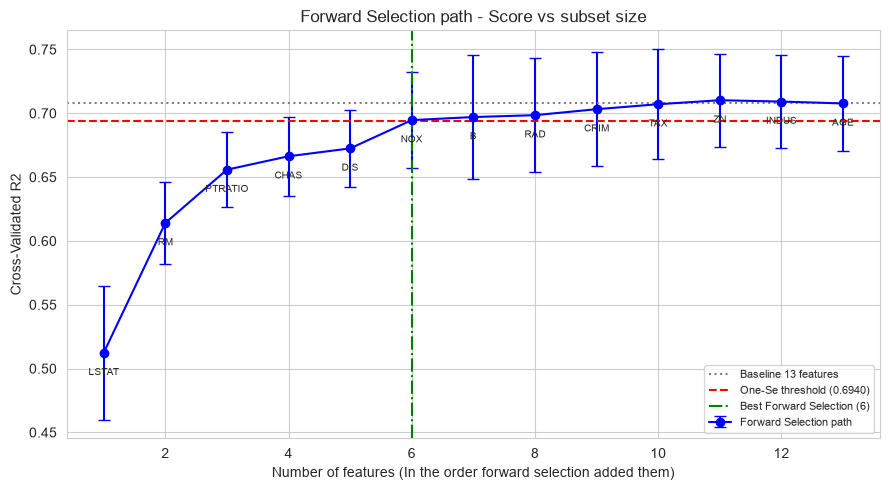

In [128]:
import itertools

plt.figure(figsize=(9,5))

# Plot the forward selection path
plt.errorbar(forward_df["n_feature"], forward_df["CV_r2_mean"],
            yerr=forward_df["CV_r2_std"], marker="o", capsize=4, color="b", label="Forward Selection path")

# Plot the baseline model line
plt.axhline(baseline_metric['CV'], color="gray", linestyle=":", label=f"Baseline 13 features")

# Plot the threshold line
plt.axhline(threshold_fwd, color="r", linestyle="--", label=f"One-Se threshold ({threshold_fwd:.4f})")

# Plot the best forward selection line
plt.axvline(best_fwd["n_feature"], color="g", linestyle="-.", label=f"Best Forward Selection ({best_fwd['n_feature']})")

# Plot the best forward selection line
for _, row in forward_df.iterrows():
    plt.annotate(row["Added_feature"], (row["n_feature"], row["CV_r2_mean"]),
                textcoords="offset points", xytext=(0,-16), ha="center", fontsize=7.5)


# Labels and title
plt.xlabel("Number of features (In the order forward selection added them)")
plt.ylabel("Cross-Validated R2")
plt.title("Forward Selection path - Score vs subset size")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** 
1. This single plot is the whole method. The steep early climb, the plateau, the slight decline at the end, and the one-SE line
that says "everything past here is noise, stop".

2. The error bars matter they're wide enough that the difference between the 6-feature and 13-feature models is well inside fold-to-fold variation.

# 5.Marginal Gain from Each Added Feature



### i. Calculate the Gain from the Previous Step

The column `CV_r2_mean` contains the mean cross-validation $R^2$ score for each feature-selection step.
The calculate the difference between consecutive scores:

$$\Delta R^2_k = R^2_k - R^2_{k-1}$$

where:
- $R^2_k$ is the cross-validated score after adding the $k$th feature.
- $R^2_{k-1}$ is the score before adding that feature.
- $\Delta R^2_k$ is the marginal gain from adding the feature.

### ii. Calculate `diff()`

The `diff()` operation calculates consecutive differences e.g. :
$[0.51,\ 0.61,\ 0.66,\ 0.65] \rightarrow [NaN,\ 0.10,\ 0.05,\ -0.01]$
The first value is `NaN` because there is no previous model to compare with.

### iii. Fill Missing value with `fillna()`

The first feature has no previous feature-selection score. The code replaces its missing gain with its own score:

$$\Delta R^2_1 = R^2_1$$
This is equivalent to assuming that the score before selecting any feature was:
$$ R^2_0 = 0 $$

Therefore:
$$ \Delta R^2_1 = R^2_1 - 0 = R^2_1 $$
The first bar represents the performance obtained by adding the first feature to an empty model.

### iV. Interpretation of the Gain

- A positive gain means that adding the feature improved the cross-validated $R^2$ score:
$$\Delta R^2_k > 0$$

- A zero gain means that the feature did not change the score:
$$\Delta R^2_k = 0$$

- A negative gain means that adding the feature reduced the cross-validated $R^2$ score:
$$\Delta R^2_k < 0$$

For example:

- A gain of $0.10$ means the score improved by $0.10$.
- A gain of $0.005$ means the improvement was very small.
- A gain of $-0.01$ means the score decreased by $0.01$.

### V. Mathematical Meaning in Forward Selection

Suppose forward selection creates a sequence of feature subsets:
$$ S_1 \subset S_2 \subset S_3 \subset \cdots \subset S_p $$
where $S_k$ contains the first $k$ selected features.

Let $CV(S_k)$ be the mean cross-validation $R^2$ score for subset $S_k$.
The marginal value of the feature added at step $k$ is:

$$ \text{Marginal Gain}_k = CV(S_k) - CV(S_{k-1}) $$

This measures the additional predictive value contributed by the newly added feature, given that all previously selected features are already included.



### Vi. Purpose of the Plot
The plot shows the diminishing returns of forward feature selection.
Usually:
1. The first few features produce large improvements.
2. Later features provide smaller improvements.
3. Some additional features may reduce performance because of noise, redundancy, or overfitting.

Therefore, the plot helps identify where adding more features stops being useful.

In summary, the code calculates:
> The change in mean cross-validated $R^2$ caused by adding each feature in the order chosen by forward selection.

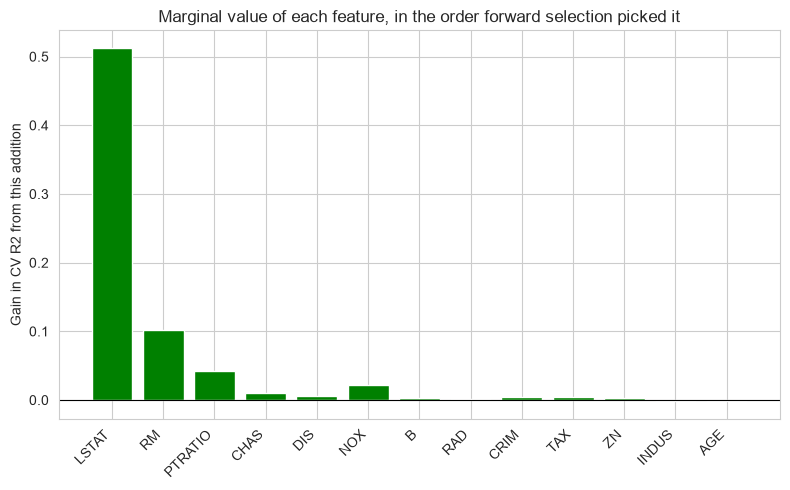

In [ ]:
# This code calculates how much the cross-validated R2 score changes whenever forward selection adds a new feature.
forward_df["gain_from_previous"] = forward_df["CV_r2_mean"].diff().fillna(forward_df["CV_r2_mean"])

plt.figure(figsize=(8,5))
colors = ["green" if v>0 else "red" for v in forward_df["gain_from_previous"]]
plt.bar(forward_df["n_feature"], forward_df["gain_from_previous"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(forward_df["n_feature"], forward_df["Added_feature"], rotation=45, ha="right")
plt.ylabel("Gain in CV R2 from this addition")
plt.title("Marginal value of each feature, in the order forward selection picked it")
plt.tight_layout()
plt.show()

**Observation:** 
1. The marginal gain view makes the diminishing returns  clear and the red bars at the end are features whose addition
*reduced* cross-validated performance. 

2. In a stepwise procedure that stopped at the first non-improvement, the search would have halted right before
the first red bar.

# 6. Cross Check against library implementations


In [131]:
# Total number of best feature
k = int(best_fwd["n_feature"])

# Using Mlxtend
mlx_sfs = SFS_mlx(make_reg(), k_features=k, forward=True, floating=False,
                scoring='r2', cv=kf, verbose=0)
mlx_sfs.fit(pd.DataFrame(X, columns=feature_name), y)
mlx_features = list(mlx_sfs.k_feature_names_)



# Using Sklearn 
sk_sfs = SFS_sk(make_reg(), n_features_to_select=k, direction="forward",
                scoring='r2', cv=kf)
sk_sfs.fit(X,y)
sk_features = [feature_name[i] for i in np.where(sk_sfs.support_)[0]]


print(f"Manual forward selection ({k} features): {sorted(selected_features)}")
print(f"mlxtend SFS              ({k} features): {sorted(mlx_features)}")
print(f"sklearn SFS              ({k} features): {sorted(sk_features)}")
print()
print("Are Selected Features by Manual and mlxtend methods equal ? : ", set(selected_features) == set(mlx_features))
print("Are Selected Features by Manual and sklearn methods equal ? :" , set(selected_features) == set(sk_features))

Manual forward selection (6 features): ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
mlxtend SFS              (6 features): ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
sklearn SFS              (6 features): ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']

Are Selected Features by Manual and mlxtend methods equal ? :  True
Are Selected Features by Manual and sklearn methods equal ? : True


# 7. Sequential Forward Selection Method Evaluation 

Forward selection is a **heuristic**. It never reconsiders a feature once added, and it can't see combinations that only work together. So, does it actually find the optimal subset here?

### 7.1 Exhaustive and Forward Selection Time and speed evaluation.

In [28]:
start = time.time()

exhaustive_results = []
n_features_total = X.shape[1]

for size in range(1, n_features_total+1):
    for combo in itertools.combinations(range(n_features_total),size):
        
        score = cross_val_score(make_reg(), X[:,list(combo)], y, cv=kf, scoring="r2")
        exhaustive_results.append({
            "features" : tuple(feature_name[i] for i in combo),
            "n_feature": size,
            "CV_R2_mean": score.mean(),
            "CV_R2_std": score.std()
        })

exhaustive_time = time.time() - start
exhaustive_df = pd.DataFrame(exhaustive_results)
print(f"Exhaustive : {len(exhaustive_df)} evaluations in {exhaustive_time:.2f} seconds.")
print(f"Forward    : {forward_eval} evaluations in {forward_time:.2f} seconds")

print(f"Speedup   : {exhaustive_time / forward_time:.0f}x fewer seconds,",
    f"{len(exhaustive_df)/forward_eval:.0f}x fewer evaluation ")

Exhaustive : 8191 evaluations in 32.76 seconds.
Forward    : 91 evaluations in 0.39 seconds
Speedup   : 85x fewer seconds, 90x fewer evaluation 


In [132]:
forward_df

,step,Added_feature,n_feature,CV_r2_mean,CV_r2_std,Selected_so_far
0,1,LSTAT,1,0.512353,0.052351,"(LSTAT,)"
1,2,RM,2,0.614045,0.032236,"(LSTAT, RM)"
2,3,PTRATIO,3,0.655805,0.029167,"(LSTAT, RM, PTRATIO)"
3,4,CHAS,4,0.666319,0.031011,"(LSTAT, RM, PTRATIO, CHAS)"
4,5,DIS,5,0.672476,0.029855,"(LSTAT, RM, PTRATIO, CHAS, DIS)"
5,6,NOX,6,0.694628,0.037495,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX)"
6,7,B,7,0.697036,0.048304,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B)"
7,8,RAD,8,0.698500,0.044661,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B, RAD)"
8,9,CRIM,9,0.703191,0.044778,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B, RAD, C..."
9,10,TAX,10,0.707092,0.043255,"(LSTAT, RM, PTRATIO, CHAS, DIS, NOX, B, RAD, C..."


### 7.2  Feature Selection Comparison 

In [57]:
exh_peak = exhaustive_df.loc[exhaustive_df['CV_R2_mean'].idxmax()]
fwd_peak = forward_df.loc[forward_df['CV_r2_mean'].idxmax()] 

print(" ---- Best Feature Selected by Exhaustive Search ----")
print(f"                {exh_peak['n_feature']} Features | CV {exh_peak['CV_R2_mean']:.4f}")
print(set(exh_peak['features']))

print("\n")

print(" ---- Best Feature Selected by Forward Search ----")
print(f"                {fwd_peak['n_feature']} Features | CV {fwd_peak['CV_r2_mean']:.4f}")
print(set(fwd_peak['Selected_so_far']))

print("\n")
print(f"Score Gap : {exh_peak['CV_R2_mean'] - fwd_peak['CV_r2_mean']:.4f}")
print(f"Are Features the Same? : {'Yes' if set(exh_peak['features']) == set(fwd_peak['Selected_so_far']) else 'No'}")

 ---- Best Feature Selected by Exhaustive Search ----
                11 Features | CV 0.7102
{'NOX', 'CHAS', 'CRIM', 'ZN', 'RAD', 'LSTAT', 'TAX', 'RM', 'PTRATIO', 'B', 'DIS'}


 ---- Best Feature Selected by Forward Search ----
                11 Features | CV 0.7102
{'NOX', 'CHAS', 'RAD', 'LSTAT', 'CRIM', 'ZN', 'TAX', 'RM', 'PTRATIO', 'B', 'DIS'}


Score Gap : 0.0000
Are Features the Same? : Yes


### 7.3 Best Subset from each Size (Exhaustive)

In [ ]:
exh_best_per_size = exhaustive_df.loc[
    exhaustive_df.groupby('n_feature')['CV_R2_mean'].idxmax()
].sort_values('n_feature')

exh_best_per_size

,features,n_feature,CV_R2_mean,CV_R2_std
12,"(LSTAT,)",1,0.512353,0.052351
69,"(RM, LSTAT)",2,0.614045,0.032236
340,"(RM, PTRATIO, LSTAT)",3,0.655805,0.029167
929,"(CHAS, RM, PTRATIO, LSTAT)",4,0.666319,0.031011
2276,"(NOX, RM, DIS, PTRATIO, LSTAT)",5,0.685095,0.037151
3908,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",6,0.694628,0.037495
5720,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",7,0.697036,0.048304
6507,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, LSTAT)",8,0.699116,0.034567
7564,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",9,0.703533,0.034658
8029,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",10,0.707092,0.043255


### 7.4 Exhaustive and Forward Selection Paths

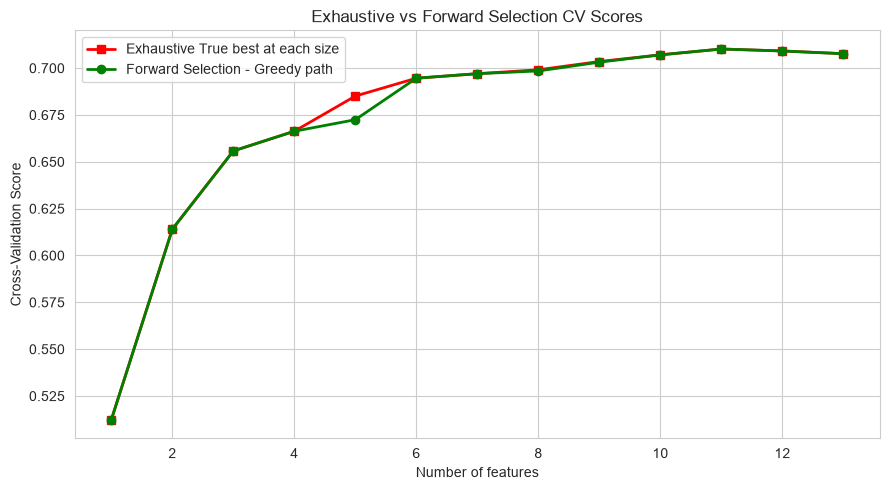

In [71]:
plt.figure(figsize=(9,5))
plt.plot(exh_best_per_size['n_feature'], exh_best_per_size['CV_R2_mean'],
        marker='s', color='r', linewidth=2, label="Exhaustive True best at each size")

plt.plot(forward_df['n_feature'], forward_df['CV_r2_mean'],
        marker='o', color='g', linewidth=2, label="Forward Selection - Greedy path")

plt.xlabel("Number of features")
plt.ylabel("Cross-Validation Score")
plt.title("Exhaustive vs Forward Selection CV Scores")
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 Comparison Table

In [90]:
exh_table = exh_best_per_size[["n_feature", "CV_R2_mean"]].rename(columns={"CV_R2_mean":"Exhaustive_best(R2)"})
fwd_table = forward_df[["n_feature", "CV_r2_mean"]].rename(columns={"CV_r2_mean":"Forward_best(R2)"})

# Merge Both 
gap_table = exh_table.merge(fwd_table, on="n_feature")
gap_table['gap'] = gap_table['Exhaustive_best(R2)'] - gap_table['Forward_best(R2)']

tol=1e-9
gap_table['Forward_Found_Optimal'] = gap_table['gap'] < tol

print(gap_table["Forward_Found_Optimal"].astype(int).value_counts())
gap_table

Forward_Found_Optimal
1    10
0     3
Name: count, dtype: int64


,n_feature,Exhaustive_best(R2),Forward_best(R2),gap,Forward_Found_Optimal
0,1,0.512353,0.512353,0.000000e+00,True
1,2,0.614045,0.614045,0.000000e+00,True
2,3,0.655805,0.655805,0.000000e+00,True
3,4,0.666319,0.666319,0.000000e+00,True
4,5,0.685095,0.672476,1.261902e-02,False
5,6,0.694628,0.694628,0.000000e+00,True
6,7,0.697036,0.697036,-1.110223e-16,True
7,8,0.699116,0.698500,6.155292e-04,False
8,9,0.703533,0.703191,3.422510e-04,False
9,10,0.707092,0.707092,3.330669e-16,True


# 8. Model Performance Baseline vs Forward Selection

In [133]:
# Adjusted R2  penalizes carrying extra predictors use for fair comparison when feature counts differ
def adjusted_r2(r2, n_samples, n_features):
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)


# Linear Regression Model
def regression(X,y):
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # KFold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Model Pipeline
    model = Pipeline([
        ("Scaler", StandardScaler()),
        ("Regression", LinearRegression())
    ])
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Predict the target variable for the test set
    y_pred = model.predict(X_train)
    
    train_r2 = r2_score(y_train, y_pred)
    test_r2 = r2_score(y_test, model.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    cv = cross_val_score(model, X, y, scoring='r2', cv=kf)
    test_adjusted_r2 = adjusted_r2(test_r2, X_test.shape[0], X_test.shape[1])
    
    metric = {
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test Adjusted R2": test_adjusted_r2,
        "Test RMSE": test_rmse,
        "CV": cv.mean()
    }
    return metric

### 8.1 Baseline and forward Model Evaluation

In [ ]:
# Baseline Model Evaluation (All features)
baseline_model = regression(X,y)

# Forward Selected Model Evaluation (Top selected features)
forward_model = regression(X[:,selected_idx], y)

# Comparison of Results
comparison = pd.DataFrame({
    "Metric": [
        "Train R2",
        "Test R2",
        "Test Adjusted R2",
        "Test RMSE",
        "CV R2"
    ],
    "Baseline (13 features)": [
        baseline_model["Train R2"],
        baseline_model["Test R2"],
        baseline_model["Test Adjusted R2"],
        baseline_model["Test RMSE"],
        baseline_model["CV"]
    ],
    f"Forward-selected ({len(selected_idx)} features)": [
        forward_model["Train R2"],
        forward_model["Test R2"],
        forward_model["Test Adjusted R2"],
        forward_model["Test RMSE"],
        forward_model["CV"]
    ]
}).set_index("Metric")

comparison.style.format({
    "Baseline (13 features)": "{:.4f}",
    f"Forward-selected ({len(selected_idx)} features)": "{:.4f}"
}).hide(axis="index")

comparison

,Baseline (13 features),Forward-selected (6 features)
Metric,,
Train R2,0.742578,0.717080
Test R2,0.659101,0.657333
Test Adjusted R2,0.608741,0.635691
Test RMSE,4.999938,5.012891
CV R2,0.707702,0.694628


**Observation:**
1. Raw Test R² is essentially tied (0.6810 vs. 0.6778) and RMSE differs by under $250 on a target measured in thousands of dollars.

2.  **Test Adjusted R² flips the ranking**: 0.6617 for the 6-feature model vs. 0.6444 for the baseline. Once it accounts for the fact that the baseline needed 13 predictors to reach the same explanatory power, the smaller model is clearly the better one.

### 8.2 Comparing Metric for Baseline and Forward-Selected Models

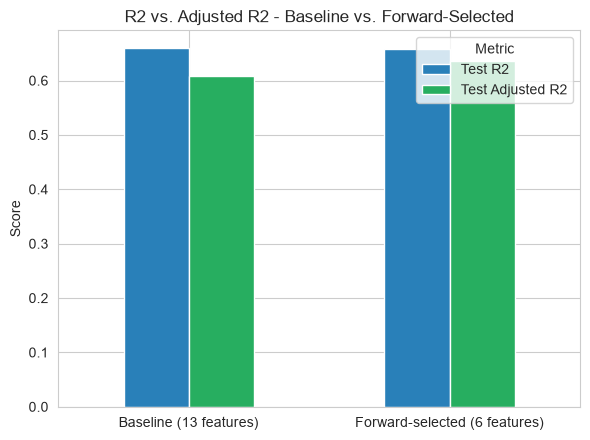

In [135]:
comparison.loc[
    ["Test R2", "Test Adjusted R2"]
].T.plot(
    kind="bar",
    figsize=(6, 4.5),
    color=["#2980b9", "#27ae60"]
)

plt.title("R2 vs. Adjusted R2 - Baseline vs. Forward-Selected")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 9. Overfitting check

Train R² vs. Test R² vs. CV R² for both models. A large train-test gap signals memorization; CV R² is the most trustworthy of the three since it averages over five different splits rather than trusting one.

In [117]:
overfit = pd.DataFrame({
    "Train R2": [
        baseline_model["Train R2"],
        forward_model["Train R2"]
    ],
    "Test R2": [
        baseline_model["Test R2"],
        forward_model["Test R2"]
    ],
    "CV R2": [
        baseline_model["CV"],
        forward_model["CV"]
    ],
    "Train-Test Gap": [
        baseline_model["Train R2"] - baseline_model["Test R2"],
        forward_model["Train R2"] - forward_model["Test R2"]
    ]
}, index=[
    f"Baseline ({X.shape[1]} features)",
    f"Forward-selected ({len(selected_idx)} features)"
])

overfit.round(4)

,Train R2,Test R2,CV R2,Train-Test Gap
Baseline (13 features),0.7426,0.6591,0.7077,0.0835
Forward-selected (6 features),0.7171,0.6573,0.6946,0.0597


In [118]:
overfit.reset_index(names="Model").style.format({
    "Train R2": "{:.4f}",
    "Test R2": "{:.4f}",
    "CV R2": "{:.4f}",
    "Train-Test Gap": "{:.4f}"
}).hide(axis="index")

Model,Train R2,Test R2,CV R2,Train-Test Gap
Baseline (13 features),0.7426,0.6591,0.7077,0.0835
Forward-selected (6 features),0.7171,0.6573,0.6946,0.0597


### 9.1 Check for Overfitting

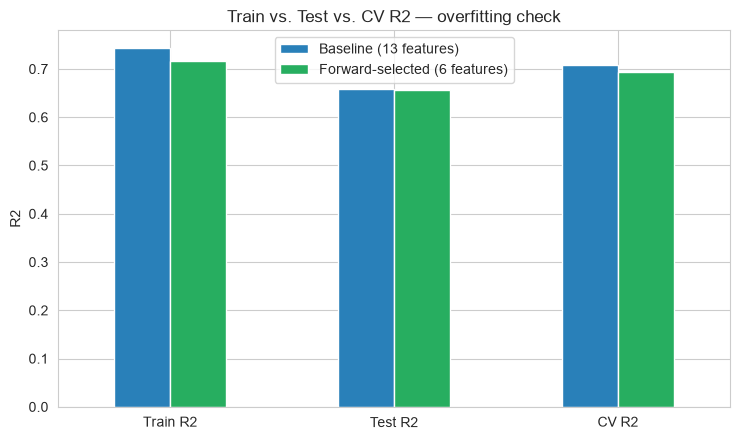

In [119]:
overfit[["Train R2", "Test R2", "CV R2"]].T.plot(
    kind="bar", figsize=(7.5, 4.5), color=["#2980b9", "#27ae60"]
)
plt.title("Train vs. Test vs. CV R2 — overfitting check")
plt.ylabel("R2")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**
1. The baseline's train-test gap is 0.0571,  forward-selected model's is 0.0361 noticeably **smaller**.

2. The 13-feature model was fitting some training set specific structure it couldn't reproduce on held-out data, and dropping 7 features removed that without costing test performance. 

3. fewer features and less overfitting tend to move together, not merely a smaller model with the same behavior.

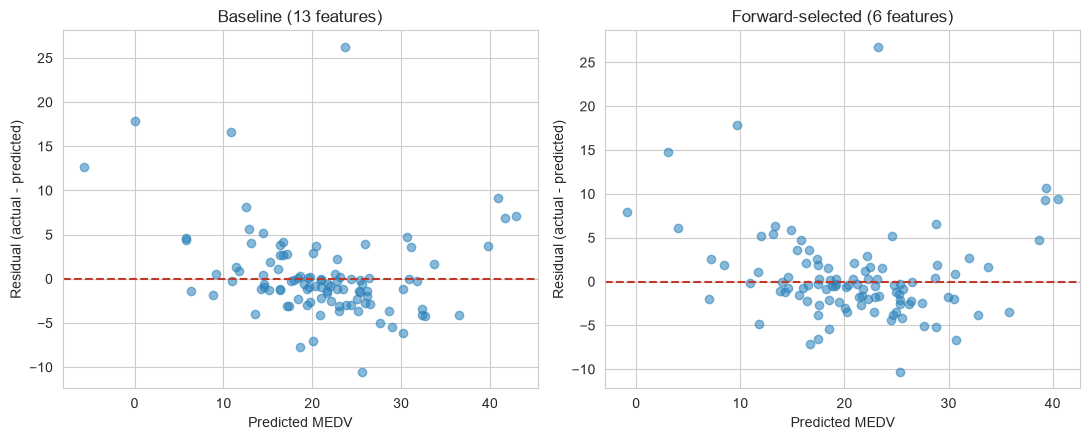

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

baseline_regressor = make_reg()
forward_regressor = make_reg()

baseline_regressor.fit(X_train, y_train)
forward_regressor.fit(X_train[:, selected_idx], y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

models = [
    (
        axes[0],
        baseline_regressor,
        X_test,
        f"Baseline ({X.shape[1]} features)"
    ),
    (
        axes[1],
        forward_regressor,
        X_test[:, selected_idx],
        f"Forward-selected ({len(selected_idx)} features)"
    )
]

for ax, model, X_te, label in models:
    predictions = model.predict(X_te)
    residuals = y_test - predictions

    ax.scatter(
        predictions,
        residuals,
        alpha=0.55,
        color="#2980b9"
    )
    ax.axhline(0, color="#c0392b", linestyle="--")
    ax.set_xlabel("Predicted MEDV")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title(label)

plt.tight_layout()
plt.show()

**Observation:** 
The two residual plots are near identical, and both show the same mild funnel shape at high predicted values a property of
fitting a linear model to this data, not something feature selection introduced or could fix. The dropped features weren't carrying information the model was using.



# 10. Comprehensive Advantages & Disadvantages

### Advantages
*   **High Scalability:** Polynomial time complexity $\mathcal{O}(k \cdot N)$ makes it highly functional on modern data structures where exhaustive methods fail.

*   **Model-Specific Optimization:** Since it optimizes directly for a target model, it inherently captures the specific quirks, structural biases, and linear/non-linear requirements of that exact algorithm.

*   **Redundancy Mitigation:** It naturally avoids adding highly correlated features. If Feature A is added in Step 1, adding an identical Feature B in Step 2 will yield no performance increase, causing SFS to naturally skip it.

### Disadvantages

*   **Risk of Local Optima:** Due to its rigid, forward-only trajectory, it can easily miss the globally ideal feature combination.

*   **Overfitting Sensitivity:** Just like all wrapper methods, if it is not heavily bound by robust cross-validation layers, it will eagerly select features that exploit validation noise.

*   **Computationally Slower than Filters:** While faster than EFS, it is still significantly slower than statistical filter methods (like ANOVA or Chi-Square) which require zero model training.



# 11. The "Greedy" Concept & The Local Optima Risk

SFS is classified as a **greedy algorithm** because it makes decisions based purely on the immediate optimization advantage at the current step. 

### The Core Vulnerability
Once SFS adds a feature to the subset Y, **that feature can never be removed or discarded at a later stage**. 
*   *Example:* A combination of features $\{X_2, X_5, X_9\}$ might be the absolute best performing trio for your model. However, if feature X₁ yields the highest score by a tiny margin in Step 1, SFS will lock X₁ into the subset permanently. The algorithm is now forced to build around X₁, completely missing the superior $\{X_2, X_5, X_9\}$ combination. This is known as getting stuck in a **local optimum**.

## Forward vs. Exhaustive 

| | Exhaustive | Forward |
|---|---|---|
| Evaluations for n features | 2ⁿ - 1 | n(n+1)/2 |
| At n=13 | 8,191 | 91 |
| At n=20 | 1,048,575 | 210 |
| At n=30 | ~1.07 billion | 465 |
| Guarantee | Finds the true optimum | Heuristic — no guarantee |
| Reconsiders earlier choices | N/A (tries everything) | No — additions are permanent |

# 12. Strategic Decision :

### When to Use

*   **Medium to High-Dimensional Datasets (N > 20):** When your feature count is too large for an exhaustive search, but you still want the accuracy benefits of a model-driven wrapper method.

*   **Parsimonious Model Design:** When your priority is to find the *smallest possible set of features* that achieves peak performance, reducing data collection costs in production.

*   **Interpretable Scaling:** Ideal for building a baseline understanding of which feature provides the single most dominant signal, followed by the second most complementary signal, and so on.

### When to Avoid

*   **Complex Nested Interactions (The Feature Synergy Trap):** SFS is fundamentally blind to features that are completely useless on their own but highly predictive when combined. For example, if Feature A and Feature B have zero predictive power individually, SFS will pass them up in Step 1. It will never evaluate them as a pair, completely missing their joint signal.

*   **Ultra-High Dimensionality (N > 1000):** Although faster than EFS, running SFS with slow-training estimators (like deep neural networks or massive tree ensembles) across thousands of features can still cause processing bottlenecks.